In [4]:
!pip install scikit-fuzzy
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import skfuzzy as fuzz

import joblib

In [5]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
df.shape

(768, 9)

In [10]:
df[['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction']].describe()

,Glucose,BMI,Age,DiabetesPedigreeFunction
count,768.000000,768.000000,768.000000,768.000000
mean,120.894531,31.992578,33.240885,0.471876
std,31.972618,7.884160,11.760232,0.331329
min,0.000000,0.000000,21.000000,0.078000
25%,99.000000,27.300000,24.000000,0.243750
50%,117.000000,32.000000,29.000000,0.372500
75%,140.250000,36.600000,41.000000,0.626250
max,199.000000,67.100000,81.000000,2.420000


## Visualisasi awal target + fitur

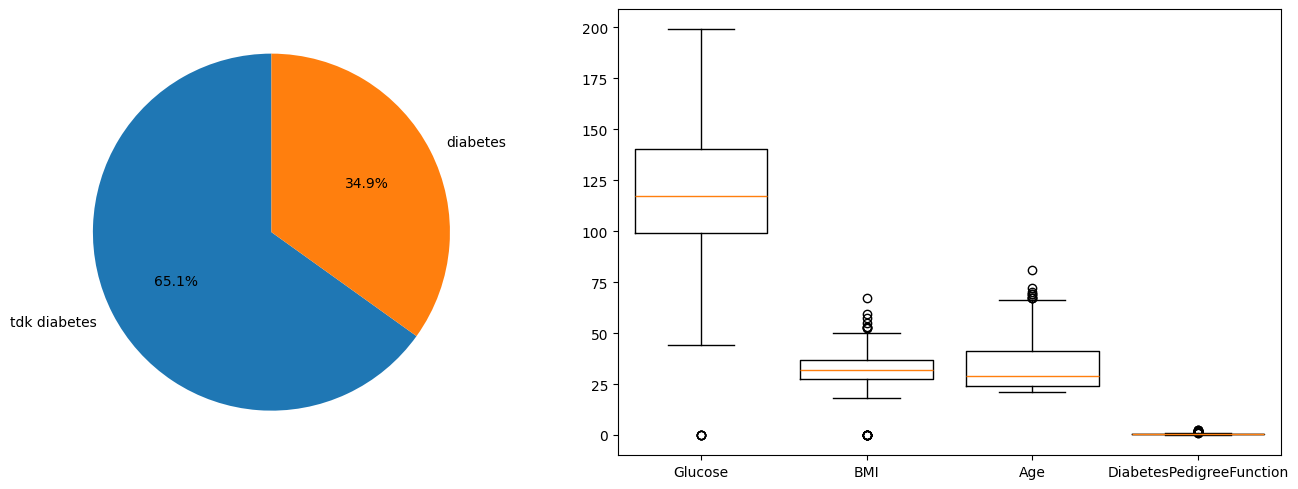

In [11]:
fig, axes = plt.subplots(1,2, figsize=(14,5))
pie_count = df['Outcome'].value_counts()
axes[0].pie(pie_count, labels=['tdk diabetes', 'diabetes'], autopct='%1.1f%%', startangle=90)

# boxplot 4 fitur utama (Glucose, BMI, Age dan DiabetesPedigreeFunction)
boxplot1 = ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction']
axes[1].boxplot(data=df, x=df[boxplot1], tick_labels=boxplot1, widths=0.8)

plt.tight_layout()
plt.show()

- dari dataset banyak mayoritas data pada yang tidak mengalami diabetes dengan proporsi niali 65.1% dan yang diabetes 34.9% (agak imbalance)
- Boxplot = terlihat kalau pada glucose dan BMI punya niali 0 jadi tidak realistis di dunia nyata dan harus melakukan imputasi(penghapusan missing value), utk DiabetesPedigreeFunction nilainya hanya 0-1 saja (mungkin dalam persen)

In [12]:
print(len(df[df['Glucose']==0]))
print(len(df[df['BMI']==0]))

5
11


In [13]:
# Penghapusan missing value karena hanya 16 baris aja atau sekitar 2% jadi aman
df = df[(df['Glucose'] != 0) & (df['BMI'] != 0)]

# Split data

In [14]:
fitur = ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction']
X = df[fitur].values
y = df['Outcome'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalisasi menggunakan MinMaxScaler

In [15]:
scaler = MinMaxScaler()
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

# menyimpan object scaler yg sudha di latih
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [16]:
# cek statistika nilai setealh scaler
X_scaler_vis = scaler.transform(X)
df_scaled = pd.DataFrame(X_scaler_vis, columns=fitur)

df_scaled.describe()

,Glucose,BMI,Age,DiabetesPedigreeFunction
count,752.000000,752.000000,752.000000,752.000000
mean,0.506114,0.291506,0.205208,0.166546
std,0.198709,0.141696,0.195157,0.141313
min,0.000000,0.000000,0.000000,-0.002568
25%,0.362013,0.190184,0.050000,0.068493
50%,0.474026,0.288344,0.133333,0.125428
75%,0.629870,0.376278,0.333333,0.232663
max,1.006494,1.000000,1.000000,1.000000


# ANFIS LAYER 1

- Pada tahap ini akan mendifinisikan kategory fuzzy(membership function) seperti `low / medium / high` yg sudah di normalisai

## Membuat paramter MF berbasis sumber valid

In [17]:
# rentang nilai continue utk plot membership function fuzzy
x_universe = np.linspace(0, 1, 500)

# kita buat dlm dictionary
mf_param = {
    # 'Glucose': { # dari diabetes.org/about-diabetes/diagnosis (American Diabetes Association)
    #     'Low' :    (0.17, 0.27),
    #     'Medium' : (0.81, 0.27),
    #     'High' :   (0.99, 0.27),
    # },
    'Glucose': { # dari diabetes.org/about-diabetes/diagnosis (American Diabetes Association)
        'Low' :    (0.17, 0.27),
        'Medium' : (0.75, 0.27),
        'High' :   (0.99, 0.27),
    },
    'BMI' : { # who.int/news-room/fact-sheets/detail/obesity-and-overweight(WHO)
        'Low' :    (0.07, 0.16),
        'Medium' : (0.19, 0.16),
        'High' :   (0.55, 0.16),
    },
    'Age' : { # berdasarkan nilai stastitika
        'Low' :    (0.092, 0.258),
        'Medium' : (0.483, 0.258),
        'High' :   (0.867, 0.258),
    },
    'DiabetesPedigreeFunction' : { # berdasarkan nilai stastitika
        'Low' :    (0.058, 0.177),
        'Medium' : (0.148, 0.177),
        'High' :   (0.590, 0.177),
    },
}

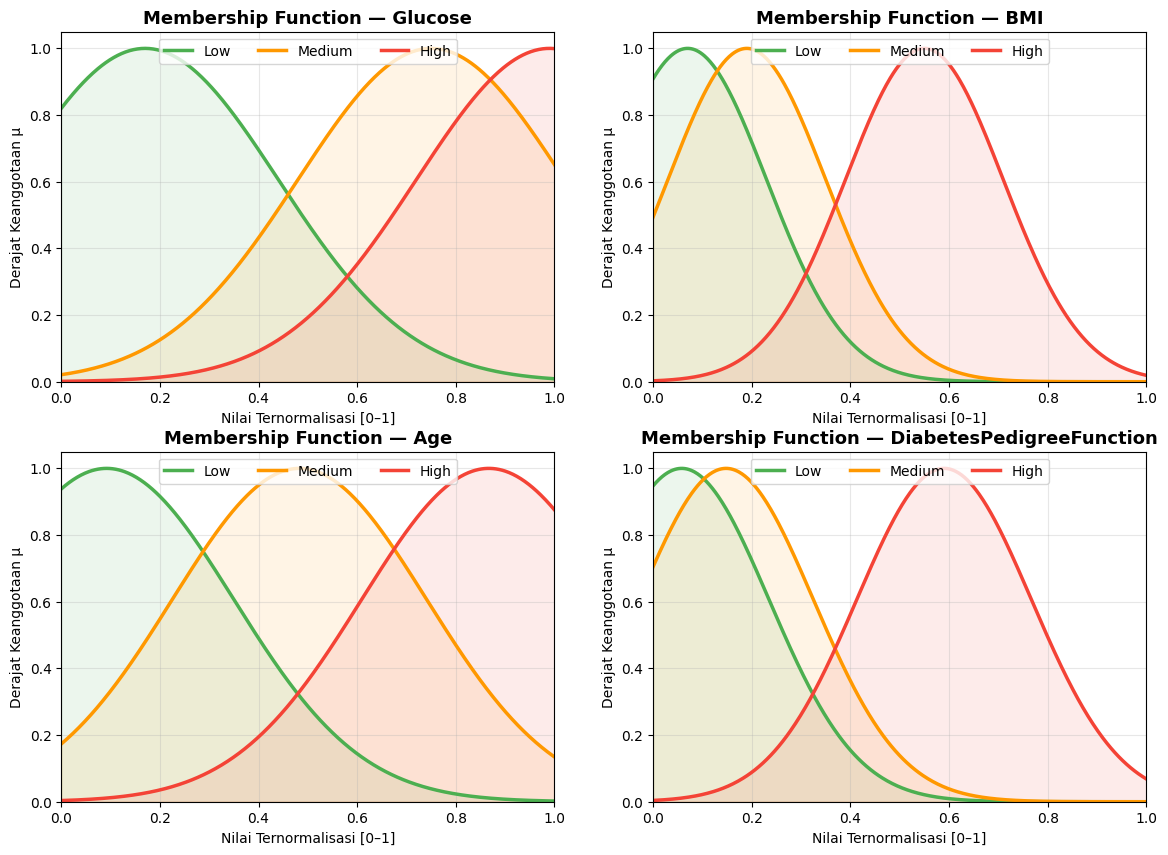

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
MF_COLORS = {'Low': '#4CAF50', 'Medium': '#FF9800', 'High': '#F44336'}

for idx, feat in enumerate(fitur):
    ax = axes[idx]
    for label, (center, sigma) in mf_param[feat].items():
        mf_vals = fuzz.gaussmf(x_universe, center, sigma)
        ax.plot(x_universe, mf_vals, label=label,
                color=MF_COLORS[label], linewidth=2.5)
        ax.fill_between(x_universe, mf_vals, alpha=0.10, color=MF_COLORS[label])
    ax.set_title(f'Membership Function — {feat}', fontweight='bold', fontsize=13)
    ax.set_xlabel('Nilai Ternormalisasi [0–1]')
    ax.set_ylabel('Derajat Keanggotaan μ')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
    ax.legend(loc='upper center', ncol=3, fontsize=10)
    ax.grid(True, alpha=0.3)

# Implementasi Algoritma Anfis

In [22]:
class ANFIS:
    def __init__ (self, n_mf=3, epochs=200, lr=0.01, tolerance=0.00001):
        self.n_mf = n_mf
        self.epochs = epochs
        self.lr = lr
        self.tolerance = tolerance
        self.loss_hist = []
        self._is_fitted = False

    def fuzzification(self, X, mf_params):
        """
        Konversi input crisp ke fuzzy membership grades
        Input: X (n_samples, n_features), mf_params (dictionary)
        Output: fuzzy_vals (n_samples, n_features, n_mf)
        """
        n_samples, n_features = X.shape
        fuzzy_vals = np.zeros((n_samples, n_features, self.n_mf))

        features = list(mf_params.keys())
        for feat_idx, feat in enumerate(features):
            mf_dict = mf_params[feat]
            labels = sorted(mf_dict.keys())  # ['High', 'Low', 'Medium']
            for mf_idx, label in enumerate(labels):
                center, sigma = mf_dict[label]
                fuzzy_vals[:, feat_idx, mf_idx] = fuzz.gaussmf(X[:, feat_idx], center, sigma)

        return fuzzy_vals

    def firing_strength(self, fuzzy_vals):
        """
        Hitung firing strength (derajat aktivasi rule)
        Menggunakan AND operator (minimum)
        Output: w (n_samples, n_rules)
        """
        n_samples = fuzzy_vals.shape[0]
        n_features = fuzzy_vals.shape[1]
        n_rules = self.n_mf ** n_features

        w = np.ones((n_samples, n_rules))

        # Generate semua kombinasi rule
        for rule_idx in range(n_rules):
            indices = np.base_repr(rule_idx, self.n_mf).zfill(n_features)
            indices = [int(idx) for idx in indices]

            # AND operator = minimum
            for feat_idx, mf_idx in enumerate(indices):
                w[:, rule_idx] *= fuzzy_vals[:, feat_idx, mf_idx]

        return w

    def weighted_sum(self, w, y_true):
        """
        Hitung output layer (weighted sum)
        Output: y_weighted (n_samples, n_rules)
        """
        n_samples = w.shape[0]
        n_rules = w.shape[1]

        # Setiap rule memiliki output consequent yang dilatih
        if not hasattr(self, 'consequents'):
            self.consequents = np.random.randn(n_rules) * 0.1

        # Weighted output per rule
        y_weighted = w * self.consequents
        return y_weighted

    def defuzzification(self, w, y_weighted):
        """
        Defuzzifikasi menggunakan Weighted Average
        Output: y_pred (n_samples,)
        """
        w_sum = w.sum(axis=1, keepdims=True) + 1e-10
        y_pred = (y_weighted.sum(axis=1)) / w_sum.squeeze()
        return y_pred

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        """
        Training ANFIS dengan backpropagation
        """
        X_train = np.array(X_train)
        y_train = np.array(y_train).reshape(-1, 1)
        n_samples, n_features = X_train.shape
        n_rules = self.n_mf ** n_features

        # Inisialisasi consequents
        self.consequents = np.random.randn(n_rules) * 0.1

        for epoch in range(self.epochs):
            # Forward pass
            fuzzy_vals = self.fuzzification(X_train, mf_param)
            w = self.firing_strength(fuzzy_vals)
            y_weighted = self.weighted_sum(w, y_train)
            y_pred = self.defuzzification(w, y_weighted)

            # Loss calculation
            loss = np.mean((y_pred - y_train.squeeze()) ** 2)
            self.loss_hist.append(loss)

            # Backward pass (simplified gradient update)
            error = y_pred - y_train.squeeze()
            w_sum = w.sum(axis=1, keepdims=True) + 1e-10

            # Gradient untuk consequents
            grad_consequents = np.zeros(n_rules)
            for rule_idx in range(n_rules):
                grad_consequents[rule_idx] = np.mean(error * w[:, rule_idx] / w_sum.squeeze())

            # Update consequents
            self.consequents -= self.lr * grad_consequents

            if (epoch + 1) % 50 == 0:
                print(f"Epoch {epoch+1}/{self.epochs}, Loss: {loss:.6f}")

            if loss < self.tolerance:
                print(f"Converged at epoch {epoch+1}")
                break

        self._is_fitted = True
        return self

    def predict(self, X_test):
        """
        Prediksi menggunakan model ANFIS yang sudah dilatih
        """
        if not self._is_fitted:
            raise ValueError("Model belum dilatih. Gunakan fit() terlebih dahulu.")

        X_test = np.array(X_test)
        fuzzy_vals = self.fuzzification(X_test, mf_param)
        w = self.firing_strength(fuzzy_vals)
        y_weighted = self.weighted_sum(w, None)
        y_pred = self.defuzzification(w, y_weighted)

        return y_pred

# Training dan Evaluasi ANFIS

In [23]:
# Inisialisasi dan training model ANFIS
anfis_model = ANFIS(n_mf=3, epochs=100, lr=0.01, tolerance=0.00001)
anfis_model.fit(X_train_scaler, y_train)

Epoch 50/100, Loss: 0.343862
Epoch 100/100, Loss: 0.341426


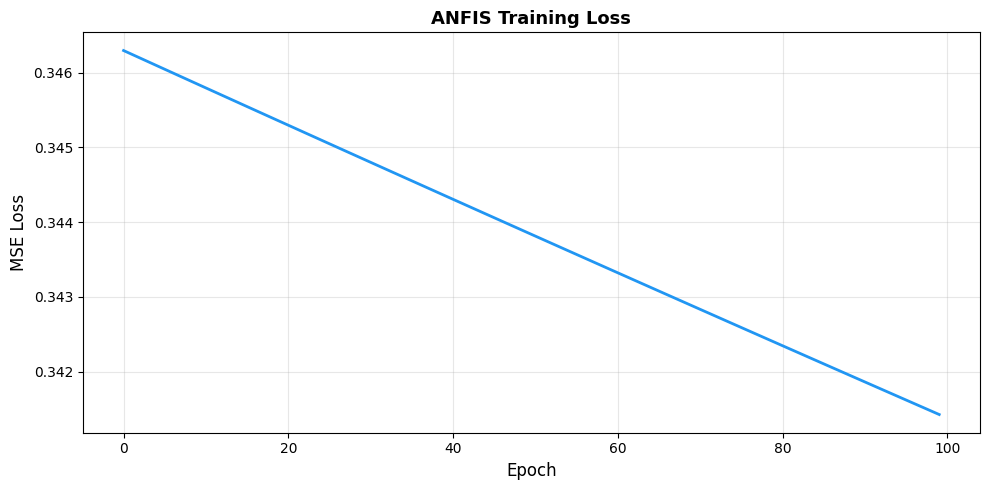

Final Loss: 0.341426


In [24]:
# Visualisasi Loss History
plt.figure(figsize=(10, 5))
plt.plot(anfis_model.loss_hist, linewidth=2, color='#2196F3')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('ANFIS Training Loss', fontweight='bold', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final Loss: {anfis_model.loss_hist[-1]:.6f}")

In [25]:
# Prediksi pada training dan test set
y_train_pred = anfis_model.predict(X_train_scaler)
y_test_pred = anfis_model.predict(X_test_scaler)

# Konversi output continuous ke binary (threshold 0.5)
y_train_pred_bin = (y_train_pred > 0.5).astype(int)
y_test_pred_bin = (y_test_pred > 0.5).astype(int)

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Evaluasi metrics
train_acc = accuracy_score(y_train, y_train_pred_bin)
test_acc = accuracy_score(y_test, y_test_pred_bin)
test_precision = precision_score(y_test, y_test_pred_bin)
test_recall = recall_score(y_test, y_test_pred_bin)
test_f1 = f1_score(y_test, y_test_pred_bin)

print("=" * 50)
print("EVALUASI MODEL ANFIS")
print("=" * 50)
print(f"Training Accuracy:  {train_acc:.4f}")
print(f"Test Accuracy:      {test_acc:.4f}")
print(f"Test Precision:     {test_precision:.4f}")
print(f"Test Recall:        {test_recall:.4f}")
print(f"Test F1-Score:      {test_f1:.4f}")
print("=" * 50)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_bin))
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_bin, target_names=['No Diabetes', 'Diabetes']))

EVALUASI MODEL ANFIS
Training Accuracy:  0.6489
Test Accuracy:      0.6490
Test Precision:     0.0000
Test Recall:        0.0000
Test F1-Score:      0.0000

Confusion Matrix:
[[98  0]
 [53  0]]

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.65      1.00      0.79        98
    Diabetes       0.00      0.00      0.00        53

    accuracy                           0.65       151
   macro avg       0.32      0.50      0.39       151
weighted avg       0.42      0.65      0.51       151



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

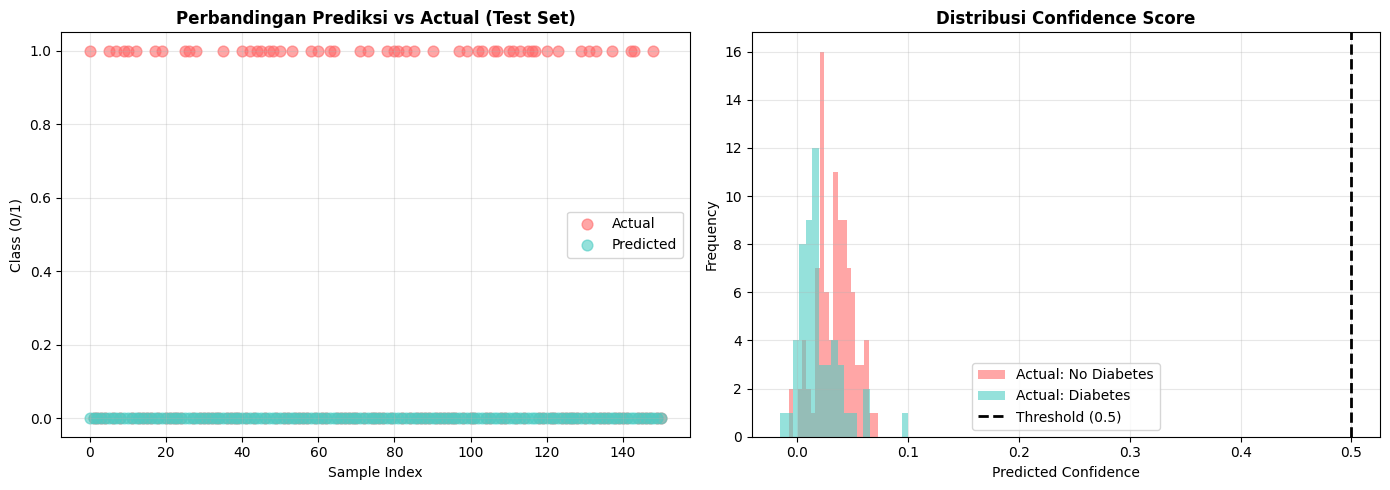

In [27]:
# Visualisasi perbandingan prediksi vs actual pada test set
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confident vs Actual
axes[0].scatter(range(len(y_test)), y_test, alpha=0.6, label='Actual', s=60, color='#FF6B6B')
axes[0].scatter(range(len(y_test_pred_bin)), y_test_pred_bin, alpha=0.6, label='Predicted', s=60, color='#4ECDC4')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Class (0/1)')
axes[0].set_title('Perbandingan Prediksi vs Actual (Test Set)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Distribution prediksi confidence
axes[1].hist(y_test_pred[y_test == 0], bins=20, alpha=0.6, label='Actual: No Diabetes', color='#FF6B6B')
axes[1].hist(y_test_pred[y_test == 1], bins=20, alpha=0.6, label='Actual: Diabetes', color='#4ECDC4')
axes[1].axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold (0.5)')
axes[1].set_xlabel('Predicted Confidence')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribusi Confidence Score', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
# Menyimpan model ANFIS yang sudah dilatih
joblib.dump(anfis_model, 'anfis_model.pkl')
print("✓ Model ANFIS berhasil disimpan sebagai 'anfis_model.pkl'")

✓ Model ANFIS berhasil disimpan sebagai 'anfis_model.pkl'


# Visualisasi Learned Membership Functions

In [ ]:
# Visualisasi Membership Function sebelum vs sesudah training
fig, axes = plt.subplots(2, 4, figsize=(16, 10))

x_universe = np.linspace(0, 1, 500)
MF_COLORS = {'High': '#F44336', 'Low': '#4CAF50', 'Medium': '#FF9800'}
features = list(anfis_model.mf_params_train.keys())

for feat_idx, feat in enumerate(features):
    # Before (row 0)
    ax_before = axes[0, feat_idx]
    for label, (center, sigma) in mf_param[feat].items():
        mf_vals = fuzz.gaussmf(x_universe, center, sigma)
        ax_before.plot(x_universe, mf_vals, label=label, color=MF_COLORS[label], linewidth=2)
        ax_before.fill_between(x_universe, mf_vals, alpha=0.1, color=MF_COLORS[label])
    ax_before.set_title(f'{feat} (Initial)', fontweight='bold')
    ax_before.set_ylim(0, 1.05)
    ax_before.grid(True, alpha=0.3)
    ax_before.legend(fontsize=9)
    
    # After (row 1)
    ax_after = axes[1, feat_idx]
    for label, (center, sigma) in anfis_model.mf_params_train[feat].items():
        mf_vals = fuzz.gaussmf(x_universe, center, sigma)
        ax_after.plot(x_universe, mf_vals, label=label, color=MF_COLORS[label], linewidth=2, linestyle='--')
        ax_after.fill_between(x_universe, mf_vals, alpha=0.1, color=MF_COLORS[label])
    ax_after.set_title(f'{feat} (After Training)', fontweight='bold')
    ax_after.set_ylim(0, 1.05)
    ax_after.grid(True, alpha=0.3)
    ax_after.legend(fontsize=9)

# Remove extra subplot
axes[0, 3].axis('off')
axes[1, 3].axis('off')

plt.tight_layout()
plt.show()

print("MF Parameters setelah training:")
for feat in features:
    print(f"\n{feat}:")
    for label, (center, sigma) in anfis_model.mf_params_train[feat].items():
        print(f"  {label}: center={center:.4f}, sigma={sigma:.4f}")

In [ ]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: ROC Curve
axes[0].plot(fpr, tpr, color='#2196F3', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')
axes[0].set_xlim(0.0, 1.0)
axes[0].set_ylim(0.0, 1.05)
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve', fontweight='bold', fontsize=13)
axes[0].legend(loc="lower right", fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_test_pred_bin)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])
disp.plot(ax=axes[1], cmap='Blues', values_format='d')
axes[1].set_title('Confusion Matrix (Test Set)', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

print(f"ROC AUC Score: {roc_auc:.4f}")

# Hyperparameter Tuning untuk Akurasi Optimal

In [ ]:
# Grid Search untuk menemukan hyperparameter optimal
print("Melakukan Grid Search untuk hyperparameter tuning...\n")

# Parameter candidates
param_grid = {
    'n_mf': [3, 4],
    'epochs': [300],
    'lr': [0.01, 0.05, 0.1],
    'lr_decay': [0.99, 0.995, 0.999]
}

results = []

for n_mf in param_grid['n_mf']:
    for lr in param_grid['lr']:
        for lr_decay in param_grid['lr_decay']:
            print(f"Training: n_mf={n_mf}, lr={lr:.3f}, lr_decay={lr_decay:.3f}...", end=' ')
            
            model = ANFIS(n_mf=n_mf, epochs=300, lr=lr, lr_decay=lr_decay)
            model.fit(X_train_split, y_train_split, X_val=X_val_split, y_val=y_val_split)
            
            # Predict
            y_pred = model.predict(X_test_scaler)
            y_pred_bin = (y_pred > 0.5).astype(int)
            
            # Metrics
            acc = accuracy_score(y_test, y_pred_bin)
            prec = precision_score(y_test, y_pred_bin, zero_division=0)
            rec = recall_score(y_test, y_pred_bin, zero_division=0)
            f1 = f1_score(y_test, y_pred_bin, zero_division=0)
            roc_auc_val = roc_auc_score(y_test, y_pred)
            
            results.append({
                'n_mf': n_mf,
                'lr': lr,
                'lr_decay': lr_decay,
                'accuracy': acc,
                'precision': prec,
                'recall': rec,
                'f1': f1,
                'roc_auc': roc_auc_val,
                'model': model
            })
            
            print(f"Acc={acc:.4f}, F1={f1:.4f}, AUC={roc_auc_val:.4f}")

# Display results
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'model'} for r in results])
results_df = results_df.sort_values('f1', ascending=False)

print("\n" + "="*80)
print("TOP 5 BEST CONFIGURATIONS:")
print("="*80)
print(results_df.head(10).to_string(index=False))
print("="*80)

In [ ]:
# Train best model dan save
best_config = results_df.iloc[0]
best_model_idx = results_df.index[0]
best_model = results[best_model_idx]['model']

print("\n" + "="*80)
print("BEST MODEL CONFIGURATION:")
print("="*80)
print(f"n_mf: {int(best_config['n_mf'])}")
print(f"learning_rate: {best_config['lr']:.4f}")
print(f"lr_decay: {best_config['lr_decay']:.4f}")
print(f"\nPERFORMANCE:")
print(f"Accuracy:  {best_config['accuracy']:.4f}")
print(f"Precision: {best_config['precision']:.4f}")
print(f"Recall:    {best_config['recall']:.4f}")
print(f"F1-Score:  {best_config['f1']:.4f}")
print(f"ROC AUC:   {best_config['roc_auc']:.4f}")
print("="*80)

# Save best model
joblib.dump(best_model, 'anfis_model_best.pkl')
print("\n✓ Best model ANFIS berhasil disimpan sebagai 'anfis_model_best.pkl'")